In [1]:
import os
import copy
import random
import numpy as np
import pandas as pd

from PIL import Image
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms, models

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix

# Load the old CNN

In [2]:
# Use metal performance shaders (MPS) if available

import torch
import torch.nn as nn
import copy

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Usando dispositivo:", device)


# ------------------------------------------------------------
# Inicialización limpia de pesos
# ------------------------------------------------------------

def reinitialize_model_weights(model):
    for module in model.modules():
        if isinstance(module, nn.Conv2d):
            nn.init.kaiming_normal_(
                module.weight,
                mode="fan_out",
                nonlinearity="relu"
            )

            if module.bias is not None:
                nn.init.zeros_(module.bias)

        elif isinstance(module, nn.Linear):
            nn.init.xavier_normal_(module.weight)

            if module.bias is not None:
                nn.init.zeros_(module.bias)

        elif isinstance(module, (nn.BatchNorm1d, nn.BatchNorm2d)):
            if module.weight is not None:
                nn.init.ones_(module.weight)

            if module.bias is not None:
                nn.init.zeros_(module.bias)

            if module.running_mean is not None:
                module.running_mean.zero_()

            if module.running_var is not None:
                module.running_var.fill_(1)


# ------------------------------------------------------------
# Cargar SOLO para recuperar arquitectura, no pesos entrenados
# ------------------------------------------------------------

model_path = "Models/Model_Exec_720_Epoch_150_cpu_portable.pth"

values = torch.load(
    model_path,
    map_location="cpu",
    weights_only=False
)

model = values["modelo"]

print("Modelo cargado como plantilla de arquitectura.")
print("Reinicializando pesos...")

reinitialize_model_weights(model)

first_weight = None

for module in model.modules():
    if isinstance(module, nn.Conv2d):
        first_weight = module.weight.detach().cpu().flatten()[:10]
        break

print("Primeros pesos después de reinicializar:")
print(first_weight)

model = model.to(device)
model.train()

print("Modelo reinicializado correctamente. No se usarán pesos entrenados previos.")

Usando dispositivo: mps
Modelo cargado como plantilla de arquitectura.
Reinicializando pesos...
Primeros pesos después de reinicializar:
tensor([-0.0074, -0.0222, -0.0010, -0.0179, -0.0089, -0.0102,  0.0004,  0.0226,
        -0.0216, -0.0044])
Modelo reinicializado correctamente. No se usarán pesos entrenados previos.


# Capture the tensor and get the vector

In [3]:
# Tensor from model to vector[1024] extractor:

class CNNEmbeddingExtractor(nn.Module):
    def __init__(self, base_model):
        super().__init__()

        self.features = nn.ModuleList([
            nn.Sequential(*copy.deepcopy(block))
            for block in base_model.features
        ])

        self.second_level = copy.deepcopy(base_model.second_level)
        self.sizes = copy.deepcopy(base_model.sizes)

    def forward(self, image):
        x = image
        prev = -1
        pos = 0
        outputs = {}

        for i in range(len(self.features)):
            if i == 0 or i == 1:
                x = self.features[i](x)
                outputs[i] = x
            else:
                connections = self.second_level[pos:pos+prev]

                for c in range(len(connections)):
                    if connections[c] == 1:
                        skip_size = self.sizes[c][0]
                        req_size = x.shape[2]

                        if skip_size > req_size:
                            psize = skip_size - req_size + 1
                            pool = nn.MaxPool2d(kernel_size=psize, stride=1)
                            x2 = pool(outputs[c])

                        elif skip_size == req_size:
                            x2 = outputs[c]

                        else:
                            if (req_size - skip_size) % 2 == 0:
                                pad = int((req_size - skip_size) / 2)
                                padding = nn.ZeroPad2d(pad)
                                x2 = padding(outputs[c])
                            else:
                                pool = nn.MaxPool2d(kernel_size=2, stride=1, padding=1)
                                x2 = pool(outputs[c])
                                pad = int((req_size - skip_size - 1) / 2)
                                if pad > 0:
                                    padding = nn.ZeroPad2d(pad)
                                    x2 = padding(x2)

                        x = torch.cat((x, x2), axis=1)

                x = self.features[i](x)
                outputs[i] = x
                pos += prev

            prev += 1

        return torch.flatten(x, 1)

# Transformer for the image

In [ ]:
#Transformer for the image

transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
])

# Create the clinical vector

In [5]:
#Check the csv
import pandas as pd

df = pd.read_csv("DataSet/dataset_maestro.csv")
print(df.shape)
print(df.columns.tolist())
df.head()

(365, 8)
['id', 'external_id', 'Clase', 'Dx Periapical', 'Sensibilidad', 'Percusión', 'Movilidad', 'Palpación']


,id,external_id,Clase,Dx Periapical,Sensibilidad,Percusión,Movilidad,Palpación
0,1. OD 22,radiografia_dataset_original/Pulpa Normal/1. O...,Pulpa Normal,Tejidos apicales normales,positivo,negativo,1,negativo
1,2. OD 25,radiografia_dataset_original/Pulpa Normal/2. O...,Pulpa Normal,Tejidos apicales normales,positivo,negativo,1,negativo
2,3. OD 14,radiografia_dataset_original/Pulpa Normal/3. O...,Pulpa Normal,Tejidos apicales normales,positivo,negativo,1,negativo
3,4. OD 25,radiografia_dataset_original/Pulpa Normal/4. O...,Pulpa Normal,Periodontitis apical sintomática,positivo,positivo,1,negativo
4,5. OD 27,radiografia_dataset_original/Pulpa Normal/5. O...,Pulpa Normal,Tejidos apicales normales,positivo,negativo,1,negativo


In [6]:
def build_clinical_vector(dx_periapical, sensibilidad, percusion, movilidad, palpacion):
    # Normalizar strings
    dx_periapical = str(dx_periapical).strip()
    sensibilidad = str(sensibilidad).strip().lower()
    percusion = str(percusion).strip().lower()
    movilidad = str(movilidad).strip()
    palpacion = str(palpacion).strip().lower()

    # Mapeo Dx Periapical
    dx_map = {
        "Periodontitis apical asintomática": [1, 0, 0, 0, 0],
        "Absceso apical crónico":            [0, 1, 0, 0, 0],
        "Periodontitis apical sintomática":  [0, 0, 1, 0, 0],
        "Tejidos apicales normales":         [0, 0, 0, 1, 0],
        "Absceso apical agudo":              [0, 0, 0, 0, 1],
    }

    # Binarias
    bin_map = {
        "positiva": 1.0,
        "positivo": 1.0,
        "negativa": 0.0,
        "negativo": 0.0,
    }

    # Movilidad
    movilidad_map = {
        "No valorable": [0, 0, 0],
        "1":            [1, 0, 0],
        "2":            [0, 1, 0],
        "3":            [0, 0, 1],  
    }

    if dx_periapical not in dx_map:
        raise ValueError(f"Dx Periapical no válido: {dx_periapical}")

    if sensibilidad not in bin_map:
        raise ValueError(f"Sensibilidad no válida: {sensibilidad}")

    if percusion not in bin_map:
        raise ValueError(f"Percusión no válida: {percusion}")

    if palpacion not in bin_map:
        raise ValueError(f"Palpación no válida: {palpacion}")

    if movilidad not in movilidad_map:
        raise ValueError(f"Movilidad no válida: {movilidad}")

    vector = (
        dx_map[dx_periapical]
        + [bin_map[sensibilidad]]
        + [bin_map[percusion]]
        + movilidad_map[movilidad]
        + [bin_map[palpacion]]
    )

    return torch.tensor(vector, dtype=torch.float32)

In [7]:
#This aren't the clases for the vector, this is for the final classification of the model.

class_to_idx = {
    "Necrosis Pulpar": 0,
    "Previamente iniciado": 1,
    "Previamente Tratado": 2,
    "Pulpa Normal": 3,
    "Pulpitis Irreversible Asintomática": 4,
    "Pulpitis Irreversible Sintomática": 5,
}

In [8]:
from pathlib import Path

def normalize_image_key(path):
    path = str(path).strip()

    # Unificar separadores
    path = path.replace("\\", "/")

    # Quitar prefijos posibles
    prefixes = [
        "DataSet/",
        "radiografia_dataset_original/",
        "DataSet/radiografia_dataset_original/",
    ]

    for prefix in prefixes:
        if path.startswith(prefix):
            path = path[len(prefix):]

    return path.strip("/")

# Data Loader

In [9]:
# Check the images
from pathlib import Path

def build_image_path_dict(root_dir, valid_exts=None):
    if valid_exts is None:
        valid_exts = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}

    root_dir = Path(root_dir)
    image_path_dict = {}
    failed_files = []

    all_files = sorted(root_dir.rglob("*"))

    for file_path in all_files:
        if file_path.is_file() and file_path.suffix.lower() in valid_exts:
            try:
                relative_key = str(file_path.relative_to(root_dir))
                relative_key = normalize_image_key(relative_key)

                image_path_dict[relative_key] = str(file_path)

            except Exception as e:
                failed_files.append((str(file_path), str(e)))

    return image_path_dict, failed_files

In [10]:
%pwd

'/Users/mauricio/Documents/Ecuela-UV/Semestre-8/Servicio/DeepGA/AddVar'

In [11]:
# Build the image path dictionary
root_dir = "DataSet/radiografia_dataset_original"

image_path_dict, failed_files = build_image_path_dict(
    root_dir=root_dir
)

print("Número de imágenes indexadas:", len(image_path_dict))
print("Número de archivos con error:", len(failed_files))

first_keys = list(image_path_dict.keys())[:10]

for k in first_keys:
    print("Clave:", k)
    print("Ruta:", image_path_dict[k])
    print()

if failed_files:
    print("Archivos con error:")
    for path, err in failed_files[:30]:
        print(path)
        print("Error:", err)
        print("-" * 50)
else:
    print("No hubo errores.")

Número de imágenes indexadas: 361
Número de archivos con error: 0
Clave: Necrosis Pulpar/1. OD 36.jpeg
Ruta: DataSet/radiografia_dataset_original/Necrosis Pulpar/1. OD 36.jpeg

Clave: Necrosis Pulpar/10. OD 16.jpg
Ruta: DataSet/radiografia_dataset_original/Necrosis Pulpar/10. OD 16.jpg

Clave: Necrosis Pulpar/100. OD 16.jpg
Ruta: DataSet/radiografia_dataset_original/Necrosis Pulpar/100. OD 16.jpg

Clave: Necrosis Pulpar/11. OD 17.jpg
Ruta: DataSet/radiografia_dataset_original/Necrosis Pulpar/11. OD 17.jpg

Clave: Necrosis Pulpar/12. OD 46.jpg
Ruta: DataSet/radiografia_dataset_original/Necrosis Pulpar/12. OD 46.jpg

Clave: Necrosis Pulpar/13. OD 14.jpg
Ruta: DataSet/radiografia_dataset_original/Necrosis Pulpar/13. OD 14.jpg

Clave: Necrosis Pulpar/14. OD 16.jpg
Ruta: DataSet/radiografia_dataset_original/Necrosis Pulpar/14. OD 16.jpg

Clave: Necrosis Pulpar/15. OD 13.jpg
Ruta: DataSet/radiografia_dataset_original/Necrosis Pulpar/15. OD 13.jpg

Clave: Necrosis Pulpar/16. OD 36.jpg
Ruta: D

In [12]:
# Create the samples

samples = []
errors = []

for idx, row in df.iterrows():
    try:
        image_key = normalize_image_key(row["external_id"])

        if image_key not in image_path_dict:
            raise KeyError(f"No se encontró imagen para: {image_key}")

        clinical_vector = build_clinical_vector(
            dx_periapical=row["Dx Periapical"],
            sensibilidad=row["Sensibilidad"],
            percusion=row["Percusión"],
            movilidad=row["Movilidad"],
            palpacion=row["Palpación"],
        )

        if row["Clase"] not in class_to_idx:
            raise KeyError(f"Clase no válida: {row['Clase']}")

        label = class_to_idx[row["Clase"]]

        samples.append({
            "image_key": image_key,
            "image_path": image_path_dict[image_key],  
            "clinical_vector": clinical_vector,         # [11]
            "label": label,                             # int
        })

    except Exception as e:
        errors.append({
            "row_idx": idx,
            "id": row.get("id", None),
            "external_id": row.get("external_id", None),
            "clase": row.get("Clase", None),
            "dx_periapical": row.get("Dx Periapical", None),
            "sensibilidad": row.get("Sensibilidad", None),
            "percusion": row.get("Percusión", None),
            "movilidad": row.get("Movilidad", None),
            "palpacion": row.get("Palpación", None),
            "error": str(e),
        })

print("Samples válidos:", len(samples))
print("Errores:", len(errors))

for err in errors:
    print("=" * 80)
    print(f"Fila: {err['row_idx']}")
    print(f"id: {err['id']}")
    print(f"external_id: {err['external_id']}")
    print(f"Clase: {err['clase']}")
    print(f"Dx Periapical: {err['dx_periapical']}")
    print(f"Sensibilidad: {err['sensibilidad']}")
    print(f"Percusión: {err['percusion']}")
    print(f"Movilidad: {err['movilidad']}")
    print(f"Palpación: {err['palpacion']}")
    print(f"Error: {err['error']}")

Samples válidos: 359
Errores: 6
Fila: 61
id: 1. OD 34
external_id: Pulpitis reversible/1er OD 34.jpeg
Clase: Pulpitis Reversible
Dx Periapical: Tejidos apicales normales
Sensibilidad: positivo
Percusión: negativo
Movilidad: 1
Palpación: negativo
Error: 'No se encontró imagen para: Pulpitis reversible/1er OD 34.jpeg'
Fila: 62
id: 2. OD 36
external_id: Pulpitis reversible/2. OD 36.jpg
Clase: Pulpitis Reversible
Dx Periapical: Tejidos apicales normales
Sensibilidad: positivo
Percusión: negativo
Movilidad: 1
Palpación: negativo
Error: 'No se encontró imagen para: Pulpitis reversible/2. OD 36.jpg'
Fila: 63
id: 3. OD 46
external_id: Pulpitis reversible/3. OD 46.jpg
Clase: Pulpitis Reversible
Dx Periapical: Tejidos apicales normales
Sensibilidad: positivo
Percusión: negativo
Movilidad: 1
Palpación: negativo
Error: 'No se encontró imagen para: Pulpitis reversible/3. OD 46.jpg'
Fila: 64
id: 4. OD 21
external_id: Pulpitis reversible/4. OD 21.jpg
Clase: Pulpitis Reversible
Dx Periapical: Periodon

In [13]:
# Data set Class for the stratification
from torch.utils.data import Dataset
from PIL import Image
import torch

class FullMultimodalFolderDataset(Dataset):
    def __init__(self, samples, transform=None):
        self.samples = samples
        self.transform = transform
        self.targets = [s["label"] for s in samples]

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]

        image = Image.open(sample["image_path"]).convert("RGB")
        if self.transform is not None:
            image = self.transform(image)

        clinical = torch.tensor(sample["clinical_vector"], dtype=torch.float32)
        label = torch.tensor(sample["label"], dtype=torch.long)

        return image, clinical, label

In [14]:
# make the stratified splits

import numpy as np
from sklearn.model_selection import StratifiedShuffleSplit

def make_stratified_splits(targets, val_split=0.15, test_split=0.15, seed=42):
    y = np.array(targets)
    idx = np.arange(len(y))

    # train+val vs test
    sss_test = StratifiedShuffleSplit(
        n_splits=1,
        test_size=test_split,
        random_state=seed
    )
    trainval_idx, test_idx = next(sss_test.split(idx, y))

    # train vs val
    y_trainval = y[trainval_idx]
    val_rel = val_split / (1.0 - test_split)

    sss_val = StratifiedShuffleSplit(
        n_splits=1,
        test_size=val_rel,
        random_state=seed
    )
    train_rel, val_rel_idx = next(sss_val.split(trainval_idx, y_trainval))

    train_idx = trainval_idx[train_rel]
    val_idx = trainval_idx[val_rel_idx]

    return {
        "train_idx": train_idx,
        "val_idx": val_idx,
        "test_idx": test_idx,
    }

In [15]:
# Data loader

import torch
from torch.utils.data import DataLoader, Subset

def make_multimodal_dataloaders(
    ds,
    train_idx,
    val_idx,
    test_idx,
    batch_size=64,
    num_workers=4,
    seed=42,
):
    g = torch.Generator()
    g.manual_seed(seed)

    pin = torch.backends.mps.is_available()

    train_dl = DataLoader(
        Subset(ds, train_idx),
        batch_size=batch_size,
        shuffle=True,
        generator=g,
        num_workers=num_workers,
        pin_memory=pin,
    )

    val_dl = DataLoader(
        Subset(ds, val_idx),
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=pin,
    )

    test_dl = DataLoader(
        Subset(ds, test_idx),
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=pin,
    )

    return {
        "train": train_dl,
        "val": val_dl,
        "test": test_dl,
    }

In [16]:
# Use the Data loader
def load_data_module(
    samples,
    batch_size=64,
    val_split=0.15,
    test_split=0.15,
    seed=42,
    num_workers=0
):
    ds = FullMultimodalFolderDataset(
        samples=samples,
        transform=transform
    )

    splits = make_stratified_splits(
        targets=ds.targets,
        val_split=val_split,
        test_split=test_split,
        seed=seed,
    )

    loaders = make_multimodal_dataloaders(
        ds=ds,
        train_idx=splits["train_idx"],
        val_idx=splits["val_idx"],
        test_idx=splits["test_idx"],
        batch_size=batch_size,
        num_workers=num_workers,
        seed=seed,
    )

    return {
        "dataset": ds,
        "loaders": loaders,
        "splits": splits,
    }

In [17]:
# Functions to show the distribution of classes in each split

from collections import Counter
from pathlib import Path
import numpy as np


def show_split_distribution(ds, split_idx, name, idx_to_class):
    labels = [ds.targets[i] for i in split_idx]
    counts = Counter(labels)
    total = len(labels)

    print(f"\n{name} total = {total}")
    for class_idx in sorted(idx_to_class.keys()):
        class_name = idx_to_class[class_idx]
        n = counts.get(class_idx, 0)
        pct = (n / total) * 100 if total > 0 else 0
        print(f"  {class_name:<35} {n:>3}  ({pct:>5.2f}%)")


def print_split_files(ds, split_idx, name, idx_to_class, max_files=None, show_clinical=True):
    print("\n" + "=" * 120)
    print(f"{name} FILES | total = {len(split_idx)}")
    print("=" * 120)

    for count, idx in enumerate(split_idx):
        sample = ds.samples[idx]

        image_key = sample.get("image_key", "NO_IMAGE_KEY")
        image_path = sample.get("image_path", "NO_IMAGE_PATH")
        label = sample.get("label", None)
        class_name = idx_to_class.get(label, "UNKNOWN_CLASS")
        clinical_vector = sample.get("clinical_vector", None)

        print("-" * 120)
        print(f"{count + 1:04d} | idx={idx}")
        print(f"class      : {label} | {class_name}")
        print(f"image_key  : {image_key}")
        print(f"file       : {Path(image_path).name}")
        print(f"path       : {image_path}")

        if show_clinical:
            print(f"clinical   : {clinical_vector}")

        if max_files is not None and count + 1 >= max_files:
            remaining = len(split_idx) - max_files
            if remaining > 0:
                print("-" * 120)
                print(f"... {remaining} archivos restantes no mostrados")
            break


def check_split_index_leakage(train_idx, val_idx, test_idx):
    train_set = set(train_idx)
    val_set = set(val_idx)
    test_set = set(test_idx)

    train_val_overlap = train_set.intersection(val_set)
    train_test_overlap = train_set.intersection(test_set)
    val_test_overlap = val_set.intersection(test_set)

    print("\n" + "=" * 90)
    print("DATA LEAKAGE CHECK BY INDEX")
    print("=" * 90)
    print("Train ∩ Val :", len(train_val_overlap))
    print("Train ∩ Test:", len(train_test_overlap))
    print("Val ∩ Test  :", len(val_test_overlap))

    if train_val_overlap or train_test_overlap or val_test_overlap:
        print("\n❌ Hay índices repetidos entre splits.")

        if train_val_overlap:
            print("TRAIN / VAL overlap:", sorted(train_val_overlap))

        if train_test_overlap:
            print("TRAIN / TEST overlap:", sorted(train_test_overlap))

        if val_test_overlap:
            print("VAL / TEST overlap:", sorted(val_test_overlap))

        raise AssertionError("Se detectó leakage por índice.")

    print("✅ Sin leakage por índice.")


def check_split_file_path_leakage(ds, train_idx, val_idx, test_idx):
    def get_paths(indices):
        return {
            Path(ds.samples[i]["image_path"]).resolve()
            for i in indices
        }

    train_paths = get_paths(train_idx)
    val_paths = get_paths(val_idx)
    test_paths = get_paths(test_idx)

    train_val_overlap = train_paths.intersection(val_paths)
    train_test_overlap = train_paths.intersection(test_paths)
    val_test_overlap = val_paths.intersection(test_paths)

    print("\n" + "=" * 90)
    print("DATA LEAKAGE CHECK BY EXACT FILE PATH")
    print("=" * 90)
    print("Train ∩ Val :", len(train_val_overlap))
    print("Train ∩ Test:", len(train_test_overlap))
    print("Val ∩ Test  :", len(val_test_overlap))

    if train_val_overlap or train_test_overlap or val_test_overlap:
        print("\n❌ Hay rutas exactas repetidas entre splits.")

        if train_val_overlap:
            print("\nArchivos repetidos entre TRAIN y VAL:")
            for p in sorted(train_val_overlap):
                print(p)

        if train_test_overlap:
            print("\nArchivos repetidos entre TRAIN y TEST:")
            for p in sorted(train_test_overlap):
                print(p)

        if val_test_overlap:
            print("\nArchivos repetidos entre VAL y TEST:")
            for p in sorted(val_test_overlap):
                print(p)

        raise AssertionError("Se detectó leakage por ruta exacta de archivo.")

    print("✅ Sin leakage por ruta exacta de archivo.")


def check_duplicate_filenames_across_splits(ds, train_idx, val_idx, test_idx):
    def filename_map(indices):
        result = {}

        for i in indices:
            sample = ds.samples[i]
            path = sample["image_path"]
            filename = Path(path).name
            label = sample["label"]

            result.setdefault(filename, []).append({
                "idx": i,
                "path": path,
                "label": label,
                "image_key": sample.get("image_key", None),
            })

        return result

    train_names = filename_map(train_idx)
    val_names = filename_map(val_idx)
    test_names = filename_map(test_idx)

    train_set = set(train_names.keys())
    val_set = set(val_names.keys())
    test_set = set(test_names.keys())

    train_val = train_set.intersection(val_set)
    train_test = train_set.intersection(test_set)
    val_test = val_set.intersection(test_set)

    print("\n" + "=" * 90)
    print("DUPLICATE FILENAME CHECK ACROSS SPLITS")
    print("=" * 90)
    print("Filename Train ∩ Val :", len(train_val))
    print("Filename Train ∩ Test:", len(train_test))
    print("Filename Val ∩ Test  :", len(val_test))

    if not train_val and not train_test and not val_test:
        print("✅ No hay nombres de archivo repetidos entre splits.")
        return

    print("⚠️ Hay nombres de archivo repetidos entre splits.")
    print("Esto no siempre es leakage si son archivos distintos, pero conviene revisarlo.")

    def print_duplicates(title, overlap, left_map, right_map):
        if not overlap:
            return

        print("\n" + title)
        for filename in sorted(overlap):
            print("-" * 90)
            print("Filename:", filename)

            print("Split A:")
            for item in left_map[filename]:
                print(
                    f"  idx={item['idx']} | "
                    f"label={item['label']} | "
                    f"image_key={item['image_key']} | "
                    f"path={item['path']}"
                )

            print("Split B:")
            for item in right_map[filename]:
                print(
                    f"  idx={item['idx']} | "
                    f"label={item['label']} | "
                    f"image_key={item['image_key']} | "
                    f"path={item['path']}"
                )

    print_duplicates("Repetidos TRAIN / VAL", train_val, train_names, val_names)
    print_duplicates("Repetidos TRAIN / TEST", train_test, train_names, test_names)
    print_duplicates("Repetidos VAL / TEST", val_test, val_names, test_names)


def check_duplicate_image_keys_across_splits(ds, train_idx, val_idx, test_idx):
    def image_key_map(indices):
        result = {}

        for i in indices:
            sample = ds.samples[i]
            image_key = sample.get("image_key", None)

            if image_key is None:
                continue

            result.setdefault(image_key, []).append({
                "idx": i,
                "path": sample["image_path"],
                "label": sample["label"],
                "image_key": image_key,
            })

        return result

    train_keys = image_key_map(train_idx)
    val_keys = image_key_map(val_idx)
    test_keys = image_key_map(test_idx)

    train_set = set(train_keys.keys())
    val_set = set(val_keys.keys())
    test_set = set(test_keys.keys())

    train_val = train_set.intersection(val_set)
    train_test = train_set.intersection(test_set)
    val_test = val_set.intersection(test_set)

    print("\n" + "=" * 90)
    print("DUPLICATE IMAGE_KEY CHECK ACROSS SPLITS")
    print("=" * 90)
    print("ImageKey Train ∩ Val :", len(train_val))
    print("ImageKey Train ∩ Test:", len(train_test))
    print("ImageKey Val ∩ Test  :", len(val_test))

    if not train_val and not train_test and not val_test:
        print("✅ No hay image_key repetidos entre splits.")
        return

    print("❌ Hay image_key repetidos entre splits.")

    def print_duplicates(title, overlap, left_map, right_map):
        if not overlap:
            return

        print("\n" + title)
        for image_key in sorted(overlap):
            print("-" * 90)
            print("Image key:", image_key)

            print("Split A:")
            for item in left_map[image_key]:
                print(
                    f"  idx={item['idx']} | "
                    f"label={item['label']} | "
                    f"path={item['path']}"
                )

            print("Split B:")
            for item in right_map[image_key]:
                print(
                    f"  idx={item['idx']} | "
                    f"label={item['label']} | "
                    f"path={item['path']}"
                )

    print_duplicates("Repetidos TRAIN / VAL", train_val, train_keys, val_keys)
    print_duplicates("Repetidos TRAIN / TEST", train_test, train_keys, test_keys)
    print_duplicates("Repetidos VAL / TEST", val_test, val_keys, test_keys)

    raise AssertionError("Se detectó leakage por image_key repetido.")


def print_data_module_summary(
    data_module,
    class_to_idx,
    print_files=True,
    max_files_per_split=None,
    show_clinical=True,
    check_filenames=True,
    check_image_keys=True,
):
    ds = data_module["dataset"]
    splits = data_module["splits"]

    train_idx = splits["train_idx"]
    val_idx = splits["val_idx"]
    test_idx = splits["test_idx"]

    idx_to_class = {v: k for k, v in class_to_idx.items()}

    print(f"Counts: {len(train_idx)} {len(val_idx)} {len(test_idx)}")

    show_split_distribution(ds, train_idx, "TRAIN", idx_to_class)
    show_split_distribution(ds, val_idx, "VAL", idx_to_class)
    show_split_distribution(ds, test_idx, "TEST", idx_to_class)

    all_idx = np.concatenate([train_idx, val_idx, test_idx])

    print("\n" + "=" * 90)
    print("GENERAL INDEX CHECK")
    print("=" * 90)
    print("¿Índices únicos?", len(all_idx) == len(set(all_idx)))
    print("¿Algún índice fuera de rango?", max(all_idx) >= len(ds))

    check_split_index_leakage(
        train_idx=train_idx,
        val_idx=val_idx,
        test_idx=test_idx,
    )

    check_split_file_path_leakage(
        ds=ds,
        train_idx=train_idx,
        val_idx=val_idx,
        test_idx=test_idx,
    )

    if check_filenames:
        check_duplicate_filenames_across_splits(
            ds=ds,
            train_idx=train_idx,
            val_idx=val_idx,
            test_idx=test_idx,
        )

    if check_image_keys:
        check_duplicate_image_keys_across_splits(
            ds=ds,
            train_idx=train_idx,
            val_idx=val_idx,
            test_idx=test_idx,
        )

    if print_files:
        print_split_files(
            ds=ds,
            split_idx=train_idx,
            name="TRAIN",
            idx_to_class=idx_to_class,
            max_files=max_files_per_split,
            show_clinical=show_clinical,
        )

        print_split_files(
            ds=ds,
            split_idx=val_idx,
            name="VAL",
            idx_to_class=idx_to_class,
            max_files=max_files_per_split,
            show_clinical=show_clinical,
        )

        print_split_files(
            ds=ds,
            split_idx=test_idx,
            name="TEST",
            idx_to_class=idx_to_class,
            max_files=max_files_per_split,
            show_clinical=show_clinical,
        )

In [18]:
# Show the distribution of classes in each split

data_module = load_data_module(samples, num_workers=0)

print_data_module_summary(
    data_module=data_module,
    class_to_idx=class_to_idx,
    print_files=True,
    max_files_per_split=None,
    show_clinical=True,
    check_filenames=True,
    check_image_keys=True,
)

Counts: 251 54 54

TRAIN total = 251
  Necrosis Pulpar                      70  (27.89%)
  Previamente iniciado                 17  ( 6.77%)
  Previamente Tratado                  30  (11.95%)
  Pulpa Normal                         43  (17.13%)
  Pulpitis Irreversible Asintomática   39  (15.54%)
  Pulpitis Irreversible Sintomática    52  (20.72%)

VAL total = 54
  Necrosis Pulpar                      15  (27.78%)
  Previamente iniciado                  4  ( 7.41%)
  Previamente Tratado                   6  (11.11%)
  Pulpa Normal                          9  (16.67%)
  Pulpitis Irreversible Asintomática    9  (16.67%)
  Pulpitis Irreversible Sintomática    11  (20.37%)

TEST total = 54
  Necrosis Pulpar                      15  (27.78%)
  Previamente iniciado                  4  ( 7.41%)
  Previamente Tratado                   7  (12.96%)
  Pulpa Normal                          9  (16.67%)
  Pulpitis Irreversible Asintomática    8  (14.81%)
  Pulpitis Irreversible Sintomática    11  (20

# Create the new model

In [19]:
import torch
import torch.nn as nn

class FusedClassifier(nn.Module):
    def __init__(
        self,
        input_dim=155,
        num_classes=6,
        dropout=0.2,
    ):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.2), 
            nn.Linear(256, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.2),  
            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        return self.net(x)

In [20]:
# Create the full model

class FullMultimodalDentalDeppGAModel(nn.Module):
    def __init__(self, embedding_extractor, fused_classifier, clinical_weight=1.0):
        super().__init__()
        self.embedding_extractor = embedding_extractor
        self.fused_classifier = fused_classifier
        self.clinical_weight = clinical_weight

    def forward(self, image, clinical_vector):
        embedding = self.embedding_extractor(image)

        clinical_vector = clinical_vector * self.clinical_weight

        x = torch.cat([embedding, clinical_vector], dim=1)
        logits = self.fused_classifier(x)

        return logits

In [21]:
#Testing if the model exists

clinical_dim = len(samples[0]["clinical_vector"])
num_classes = len(class_to_idx)

print("clinical_dim:", clinical_dim)
print("num_classes:", num_classes)

extractor = CNNEmbeddingExtractor(model)

fused_classifier = FusedClassifier(
    num_classes=num_classes,
)

full_model = FullMultimodalDentalDeppGAModel(
    embedding_extractor=extractor,
    fused_classifier=fused_classifier,
    clinical_weight=1.0,
).to(device)

print(full_model)

clinical_dim: 11
num_classes: 6
FullMultimodalDentalDeppGAModel(
  (embedding_extractor): CNNEmbeddingExtractor(
    (features): ModuleList(
      (0): Sequential(
        (0): Conv2d(1, 128, kernel_size=(7, 7), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      )
      (1): Sequential(
        (0): Conv2d(128, 8, kernel_size=(9, 9), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
      )
      (2): Sequential(
        (0): Conv2d(8, 8, kernel_size=(5, 5), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inp

In [22]:
#Testing if the model can process a batch of data

train_loader = data_module["loaders"]["train"]

images, clinical_vectors, labels = next(iter(train_loader))

images = images.to(device)
clinical_vectors = clinical_vectors.to(device)
labels = labels.to(device)

with torch.no_grad():
    embedding = full_model.embedding_extractor(images)
    outputs = full_model(images, clinical_vectors)

print("images:", images.shape)
print("clinical_vectors:", clinical_vectors.shape)
print("embedding:", embedding.shape)
print("labels:", labels.shape)
print("outputs:", outputs.shape)

/Users/mauricio/Documents/Ecuela-UV/Semestre-8/Servicio/DeepGA/.venv2/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/var/folders/tl/kwq3tjcj1ys7lmb1pyf3jdd80000gn/T/ipykernel_4190/2383641742.py:22: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  clinical = torch.tensor(sample["clinical_vector"], dtype=torch.float32)


images: torch.Size([64, 1, 128, 128])
clinical_vectors: torch.Size([64, 11])
embedding: torch.Size([64, 144])
labels: torch.Size([64])
outputs: torch.Size([64, 6])


In [23]:
images, clinical_vectors, labels = next(iter(train_loader))
print("labels en el batch:", labels)
print("unique labels:", labels.unique())
print("clinical_vectors muestra:", clinical_vectors[0])

/var/folders/tl/kwq3tjcj1ys7lmb1pyf3jdd80000gn/T/ipykernel_4190/2383641742.py:22: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  clinical = torch.tensor(sample["clinical_vector"], dtype=torch.float32)


labels en el batch: tensor([2, 1, 5, 3, 4, 5, 1, 0, 0, 2, 0, 3, 5, 2, 0, 3, 4, 4, 3, 3, 2, 0, 1, 4,
        0, 2, 3, 0, 0, 3, 3, 1, 3, 5, 0, 0, 3, 5, 4, 3, 5, 1, 1, 2, 0, 5, 3, 5,
        5, 0, 0, 2, 4, 0, 0, 5, 3, 2, 3, 0, 3, 2, 0, 4])
unique labels: tensor([0, 1, 2, 3, 4, 5])
clinical_vectors muestra: tensor([0., 0., 1., 0., 0., 0., 1., 1., 0., 0., 1.])


# Training the Full Model

In [24]:
import torch
import torch.nn as nn
import copy

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

if device.type == "mps":
    torch.set_float32_matmul_precision("high")
    print("MPS disponible")
else:
    print("Usando:", device)

full_model = full_model.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW([
    {"params": full_model.embedding_extractor.parameters(), "lr": 1e-7},
    {"params": full_model.fused_classifier.parameters(), "lr": 5e-5},
], weight_decay=5e-4)

MPS disponible


In [25]:
def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    device,
):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, clinical_vectors, labels in loader:
        images = images.to(device)
        clinical_vectors = clinical_vectors.to(device)
        labels = labels.to(device)

        optimizer.zero_grad(set_to_none=True)

        outputs = model(images, clinical_vectors)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        preds = outputs.argmax(dim=1)

        batch_total = labels.size(0)
        running_loss += loss.item() * batch_total
        correct += (preds == labels).sum().item()
        total += batch_total

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [26]:
#Test if the model can train
train_loss, train_acc = train_one_epoch(
    full_model,
    data_module["loaders"]["train"],
    criterion,
    optimizer,
    device,
)

print(f"train_loss = {train_loss:.4f}")
print(f"train_acc  = {train_acc:.4f}")

/var/folders/tl/kwq3tjcj1ys7lmb1pyf3jdd80000gn/T/ipykernel_4190/2383641742.py:22: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  clinical = torch.tensor(sample["clinical_vector"], dtype=torch.float32)


train_loss = 1.8044
train_acc  = 0.1076


In [27]:
def evaluate_one_epoch(
    model,
    loader,
    criterion,
    device,
):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.inference_mode():
        for images, clinical_vectors, labels in loader:
            images = images.to(device)
            clinical_vectors = clinical_vectors.to(device)
            labels = labels.to(device)

            outputs = model(images, clinical_vectors)
            loss = criterion(outputs, labels)

            preds = outputs.argmax(dim=1)

            batch_total = labels.size(0)
            running_loss += loss.item() * batch_total
            correct += (preds == labels).sum().item()
            total += batch_total

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [28]:
def train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    epochs=50,
    min_acc_delta=0.01,
):
    best_model_wts = copy.deepcopy(model.state_dict())

    best_val_acc = 0.0
    best_val_loss = float("inf")
    best_epoch = 0

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
    }

    scaler = torch.amp.GradScaler("mps") if device.type == "mps" else None

    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(
            model=model,
            loader=train_loader,
            criterion=criterion,
            optimizer=optimizer,
            device=device,
        )

        val_loss, val_acc = evaluate_one_epoch(
            model=model,
            loader=val_loader,
            criterion=criterion,
            device=device,
        )

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(
            f"Epoch {epoch + 1:02d}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_acc:.4f}"
        )

        acc_improved = val_acc > best_val_acc + min_acc_delta
        acc_similar_but_loss_better = (
            abs(val_acc - best_val_acc) <= min_acc_delta
            and val_loss < best_val_loss
        )

        if acc_improved or acc_similar_but_loss_better:
            best_val_acc = val_acc
            best_val_loss = val_loss
            best_epoch = epoch + 1
            best_model_wts = copy.deepcopy(model.state_dict())

            print(
                f"  ✅ Nuevo mejor modelo | "
                f"Epoch {best_epoch} | "
                f"Val Acc: {best_val_acc:.4f} | "
                f"Val Loss: {best_val_loss:.4f}"
            )

    model.load_state_dict(best_model_wts)

    print("\nMejor modelo:")
    print(f"Epoch: {best_epoch}")
    print(f"Val Acc: {best_val_acc:.4f}")
    print(f"Val Loss: {best_val_loss:.4f}")

    return model, history

In [29]:
train_loader = data_module["loaders"]["train"]
val_loader = data_module["loaders"]["val"]

#train_full_model, history = train_model(
#    model=full_model,
#    train_loader=train_loader,
#    val_loader=val_loader,
#    criterion=criterion,
#    optimizer=optimizer,
#    device=device,
#    epochs=150,
#)

In [30]:
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
)

@torch.no_grad()
def get_predictions(model, loader, device):
    model.eval()

    all_preds = []
    all_targets = []

    for images, clinical_vectors, labels in loader:
        images = images.to(device, non_blocking=True)
        clinical_vectors = clinical_vectors.to(device, non_blocking=True)

        logits = model(images, clinical_vectors)
        preds = torch.argmax(logits, dim=1).cpu().numpy()

        all_preds.extend(preds)
        all_targets.extend(labels.numpy())

    all_preds = np.array(all_preds)
    all_targets = np.array(all_targets)

    return all_targets, all_preds


def evaluate_classification_model(model, loader, device, idx_to_class):
    y_true, y_pred = get_predictions(model, loader, device)

    acc = accuracy_score(y_true, y_pred)

    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )

    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )

    labels = sorted(idx_to_class.keys())
    target_names = [idx_to_class[i] for i in labels]

    cm = confusion_matrix(y_true, y_pred, labels=labels)

    report = classification_report(
        y_true,
        y_pred,
        labels=labels,
        target_names=target_names,
        zero_division=0,
    )

    results = {
        "accuracy": acc,
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "f1_macro": f1_macro,
        "precision_weighted": precision_weighted,
        "recall_weighted": recall_weighted,
        "f1_weighted": f1_weighted,
        "confusion_matrix": cm,
        "classification_report": report,
        "y_true": y_true,
        "y_pred": y_pred,
    }

    return results

In [31]:
idx_to_class = {v: k for k, v in class_to_idx.items()}

results = evaluate_classification_model(
    #model=train_full_model,
    model=full_model,
    loader=data_module["loaders"]["test"],
    device=device,
    idx_to_class=idx_to_class,
)

print(f"Accuracy           : {results['accuracy']:.4f}")
print(f"Precision macro    : {results['precision_macro']:.4f}")
print(f"Recall macro       : {results['recall_macro']:.4f}")
print(f"F1 macro           : {results['f1_macro']:.4f}")
print(f"Precision weighted : {results['precision_weighted']:.4f}")
print(f"Recall weighted    : {results['recall_weighted']:.4f}")
print(f"F1 weighted        : {results['f1_weighted']:.4f}")

print("\nClassification report:\n")
print(results["classification_report"])

print("Confusion matrix:\n")
print(results["confusion_matrix"])

/var/folders/tl/kwq3tjcj1ys7lmb1pyf3jdd80000gn/T/ipykernel_4190/2383641742.py:22: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  clinical = torch.tensor(sample["clinical_vector"], dtype=torch.float32)


Accuracy           : 0.1296
Precision macro    : 0.0243
Recall macro       : 0.1667
F1 macro           : 0.0424
Precision weighted : 0.0189
Recall weighted    : 0.1296
F1 weighted        : 0.0330

Classification report:

                                    precision    recall  f1-score   support

                   Necrosis Pulpar       0.00      0.00      0.00        15
              Previamente iniciado       0.00      0.00      0.00         4
               Previamente Tratado       0.15      1.00      0.25         7
                      Pulpa Normal       0.00      0.00      0.00         9
Pulpitis Irreversible Asintomática       0.00      0.00      0.00         8
 Pulpitis Irreversible Sintomática       0.00      0.00      0.00        11

                          accuracy                           0.13        54
                         macro avg       0.02      0.17      0.04        54
                      weighted avg       0.02      0.13      0.03        54

Confusion matrix

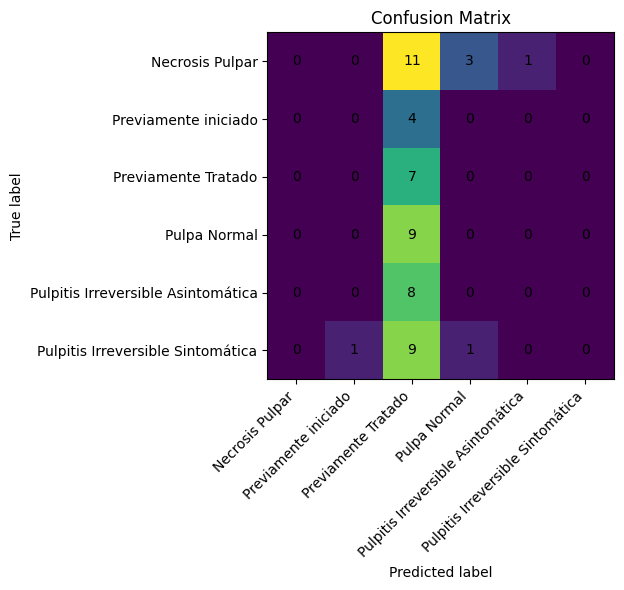

In [32]:
import matplotlib.pyplot as plt

def plot_confusion_matrix(cm, idx_to_class):
    labels = [idx_to_class[i] for i in sorted(idx_to_class.keys())]

    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(cm)

    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))

    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_yticklabels(labels)

    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_title("Confusion Matrix")

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha="center", va="center")

    plt.tight_layout()
    plt.show()

plot_confusion_matrix(results["confusion_matrix"], idx_to_class)


In [33]:
from collections import Counter

test_loader = data_module["loaders"]["test"]

loader_labels = []

for images, clinical_vectors, labels in test_loader:
    loader_labels.extend(labels.numpy().tolist())

print("Total labels desde test_loader:", len(loader_labels))
print("Distribución desde test_loader:")

for class_idx, count in sorted(Counter(loader_labels).items()):
    print(class_idx, idx_to_class[class_idx], count)

/Users/mauricio/Documents/Ecuela-UV/Semestre-8/Servicio/DeepGA/.venv2/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/var/folders/tl/kwq3tjcj1ys7lmb1pyf3jdd80000gn/T/ipykernel_4190/2383641742.py:22: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  clinical = torch.tensor(sample["clinical_vector"], dtype=torch.float32)


Total labels desde test_loader: 54
Distribución desde test_loader:
0 Necrosis Pulpar 15
1 Previamente iniciado 4
2 Previamente Tratado 7
3 Pulpa Normal 9
4 Pulpitis Irreversible Asintomática 8
5 Pulpitis Irreversible Sintomática 11


# Cross validation of the model

In [34]:
from sklearn.model_selection import StratifiedKFold
from torch.utils.data import DataLoader, Subset
import pandas as pd
import numpy as np
import copy
import torch
import torch.nn as nn

K_FOLDS = 5
KFOLD_EPOCHS = 150
KFOLD_BATCH_SIZE = 64
KFOLD_NUM_WORKERS = 0
KFOLD_SEED = 42

In [35]:
def build_fresh_full_model():
 
    extractor = CNNEmbeddingExtractor(model)

    fused_classifier = FusedClassifier(
        num_classes=len(class_to_idx),
    )

    fold_model = FullMultimodalDentalDeppGAModel(
        embedding_extractor=extractor,
        fused_classifier=fused_classifier,
    ).to(device)

    return fold_model


def build_optimizer_for_full_model(fold_model):
   
    optimizer = torch.optim.AdamW([
        {"params": fold_model.embedding_extractor.parameters(), "lr": 1e-6},
        {"params": fold_model.fused_classifier.parameters(), "lr": 3e-4},
    ], weight_decay=5e-4)

    return optimizer


def make_fold_loaders(ds, train_indices, val_indices, batch_size=64, num_workers=0, seed=42):
    g = torch.Generator()
    g.manual_seed(seed)

    pin = torch.backends.mps.is_available()

    train_loader = DataLoader(
        Subset(ds, train_indices),
        batch_size=batch_size,
        shuffle=True,
        generator=g,
        num_workers=num_workers,
        pin_memory=pin,
    )

    val_loader = DataLoader(
        Subset(ds, val_indices),
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=pin,
    )

    return train_loader, val_loader

In [36]:
ds = data_module["dataset"]

train_idx = np.array(data_module["splits"]["train_idx"])
val_idx = np.array(data_module["splits"]["val_idx"])
test_idx = np.array(data_module["splits"]["test_idx"])

# K-Fold SOLO con train + val
kfold_pool_idx = np.concatenate([train_idx, val_idx])
kfold_pool_labels = np.array([ds.targets[i] for i in kfold_pool_idx])

print("Total train original:", len(train_idx))
print("Total val original:", len(val_idx))
print("Total test hold-out:", len(test_idx))
print("Total usado en K-Fold train+val:", len(kfold_pool_idx))

# Validaciones formales
assert len(set(train_idx).intersection(set(test_idx))) == 0
assert len(set(val_idx).intersection(set(test_idx))) == 0
assert len(set(kfold_pool_idx).intersection(set(test_idx))) == 0

print("✅ Sin data leakage: test_idx NO se usa dentro del K-Fold.")

Total train original: 251
Total val original: 54
Total test hold-out: 54
Total usado en K-Fold train+val: 305
✅ Sin data leakage: test_idx NO se usa dentro del K-Fold.


In [37]:
def print_first_clinical_vectors_from_loader(loader, idx_to_class, name, n=3):
    print("\n" + "-" * 70)
    print(f"Primeros {n} vectores clínicos usados en {name}")
    print("-" * 70)

    images, clinical_vectors, labels = next(iter(loader))

    for i in range(min(n, clinical_vectors.size(0))):
        label_idx = int(labels[i].item())
        class_name = idx_to_class.get(label_idx, "UNKNOWN")

        print(f"{name} sample {i + 1}")
        print(f"  label index : {label_idx}")
        print(f"  class       : {class_name}")
        print(f"  clinical    : {clinical_vectors[i]}")

In [38]:
idx_to_class = {v: k for k, v in class_to_idx.items()}

skf = StratifiedKFold(
    n_splits=K_FOLDS,
    shuffle=True,
    random_state=KFOLD_SEED,
)

fold_results = []
fold_histories = []

for fold, (train_pos, val_pos) in enumerate(skf.split(kfold_pool_idx, kfold_pool_labels), start=1):
    print("\n" + "=" * 70)
    print(f"FOLD {fold}/{K_FOLDS}")
    print("=" * 70)

    fold_train_idx = kfold_pool_idx[train_pos]
    fold_val_idx = kfold_pool_idx[val_pos]

    # Seguridad: el test nunca debe aparecer aquí
    assert len(set(fold_train_idx).intersection(set(test_idx))) == 0
    assert len(set(fold_val_idx).intersection(set(test_idx))) == 0
    assert len(set(fold_train_idx).intersection(set(fold_val_idx))) == 0

    print("Train fold:", len(fold_train_idx))
    print("Val fold:", len(fold_val_idx))

    show_split_distribution(ds, fold_train_idx, f"FOLD {fold} TRAIN", idx_to_class)
    show_split_distribution(ds, fold_val_idx, f"FOLD {fold} VAL", idx_to_class)

    fold_train_loader, fold_val_loader = make_fold_loaders(
        ds=ds,
        train_indices=fold_train_idx,
        val_indices=fold_val_idx,
        batch_size=KFOLD_BATCH_SIZE,
        num_workers=KFOLD_NUM_WORKERS,
        seed=KFOLD_SEED + fold,
    )

    print_first_clinical_vectors_from_loader(
        loader=fold_train_loader,
        idx_to_class=idx_to_class,
        name=f"FOLD {fold} TRAIN",
        n=3,
    )

    print_first_clinical_vectors_from_loader(
        loader=fold_val_loader,
        idx_to_class=idx_to_class,
        name=f"FOLD {fold} VAL",
        n=3,
    )

    fold_model = build_fresh_full_model()

    fold_criterion = nn.CrossEntropyLoss()

    fold_optimizer = build_optimizer_for_full_model(fold_model)

    fold_model, fold_history = train_model(
        model=fold_model,
        train_loader=fold_train_loader,
        val_loader=fold_val_loader,
        criterion=fold_criterion,
        optimizer=fold_optimizer,
        device=device,
        epochs=KFOLD_EPOCHS,
    )

    fold_eval = evaluate_classification_model(
        model=fold_model,
        loader=fold_val_loader,
        device=device,
        idx_to_class=idx_to_class,
    )

    fold_row = {
        "fold": fold,
        "accuracy": fold_eval["accuracy"],
        "precision_macro": fold_eval["precision_macro"],
        "recall_macro": fold_eval["recall_macro"],
        "f1_macro": fold_eval["f1_macro"],
        "precision_weighted": fold_eval["precision_weighted"],
        "recall_weighted": fold_eval["recall_weighted"],
        "f1_weighted": fold_eval["f1_weighted"],
    }

    fold_results.append(fold_row)
    fold_histories.append(fold_history)

    print("\nResultados del fold:")
    for key, value in fold_row.items():
        if key != "fold":
            print(f"{key}: {value:.4f}")

    print("\nClassification report:")
    print(fold_eval["classification_report"])


FOLD 1/5
Train fold: 244
Val fold: 61

FOLD 1 TRAIN total = 244
  Necrosis Pulpar                      68  (27.87%)
  Previamente iniciado                 16  ( 6.56%)
  Previamente Tratado                  29  (11.89%)
  Pulpa Normal                         42  (17.21%)
  Pulpitis Irreversible Asintomática   39  (15.98%)
  Pulpitis Irreversible Sintomática    50  (20.49%)

FOLD 1 VAL total = 61
  Necrosis Pulpar                      17  (27.87%)
  Previamente iniciado                  5  ( 8.20%)
  Previamente Tratado                   7  (11.48%)
  Pulpa Normal                         10  (16.39%)
  Pulpitis Irreversible Asintomática    9  (14.75%)
  Pulpitis Irreversible Sintomática    13  (21.31%)

----------------------------------------------------------------------
Primeros 3 vectores clínicos usados en FOLD 1 TRAIN
----------------------------------------------------------------------


/Users/mauricio/Documents/Ecuela-UV/Semestre-8/Servicio/DeepGA/.venv2/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/var/folders/tl/kwq3tjcj1ys7lmb1pyf3jdd80000gn/T/ipykernel_4190/2383641742.py:22: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  clinical = torch.tensor(sample["clinical_vector"], dtype=torch.float32)


FOLD 1 TRAIN sample 1
  label index : 4
  class       : Pulpitis Irreversible Asintomática
  clinical    : tensor([0., 0., 1., 0., 0., 1., 1., 1., 0., 0., 1.])
FOLD 1 TRAIN sample 2
  label index : 4
  class       : Pulpitis Irreversible Asintomática
  clinical    : tensor([0., 0., 0., 1., 0., 0., 0., 1., 0., 0., 0.])
FOLD 1 TRAIN sample 3
  label index : 3
  class       : Pulpa Normal
  clinical    : tensor([0., 0., 0., 1., 0., 1., 0., 1., 0., 0., 0.])

----------------------------------------------------------------------
Primeros 3 vectores clínicos usados en FOLD 1 VAL
----------------------------------------------------------------------
FOLD 1 VAL sample 1
  label index : 1
  class       : Previamente iniciado
  clinical    : tensor([0., 0., 1., 0., 0., 0., 1., 1., 0., 0., 0.])
FOLD 1 VAL sample 2
  label index : 0
  class       : Necrosis Pulpar
  clinical    : tensor([0., 0., 1., 0., 0., 0., 1., 1., 0., 0., 0.])
FOLD 1 VAL sample 3
  label index : 5
  class       : Pulpitis Irr

/Users/mauricio/Documents/Ecuela-UV/Semestre-8/Servicio/DeepGA/.venv2/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/var/folders/tl/kwq3tjcj1ys7lmb1pyf3jdd80000gn/T/ipykernel_4190/2383641742.py:22: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  clinical = torch.tensor(sample["clinical_vector"], dtype=torch.float32)


FOLD 2 TRAIN sample 1
  label index : 4
  class       : Pulpitis Irreversible Asintomática
  clinical    : tensor([1., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0.])
FOLD 2 TRAIN sample 2
  label index : 0
  class       : Necrosis Pulpar
  clinical    : tensor([1., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.])
FOLD 2 TRAIN sample 3
  label index : 4
  class       : Pulpitis Irreversible Asintomática
  clinical    : tensor([0., 0., 0., 1., 0., 1., 0., 1., 0., 0., 0.])

----------------------------------------------------------------------
Primeros 3 vectores clínicos usados en FOLD 2 VAL
----------------------------------------------------------------------
FOLD 2 VAL sample 1
  label index : 4
  class       : Pulpitis Irreversible Asintomática
  clinical    : tensor([0., 0., 0., 1., 0., 1., 0., 1., 0., 0., 0.])
FOLD 2 VAL sample 2
  label index : 1
  class       : Previamente iniciado
  clinical    : tensor([0., 0., 1., 0., 0., 0., 1., 1., 0., 0., 0.])
FOLD 2 VAL sample 3
  label index : 1
  clas

...

FOLD 3 TRAIN sample 1
  label index : 3
  class       : Pulpa Normal
  clinical    : tensor([0., 0., 0., 1., 0., 1., 0., 1., 0., 0., 0.])
FOLD 3 TRAIN sample 2
  label index : 0
  class       : Necrosis Pulpar
  clinical    : tensor([0., 0., 1., 0., 0., 0., 1., 1., 0., 0., 1.])
FOLD 3 TRAIN sample 3
  label index : 0
  class       : Necrosis Pulpar
  clinical    : tensor([0., 0., 1., 0., 0., 0., 1., 1., 0., 0., 0.])

----------------------------------------------------------------------
Primeros 3 vectores clínicos usados en FOLD 3 VAL
----------------------------------------------------------------------
FOLD 3 VAL sample 1
  label index : 5
  class       : Pulpitis Irreversible Sintomática
  clinical    : tensor([0., 0., 1., 0., 0., 1., 1., 1., 0., 0., 1.])
FOLD 3 VAL sample 2
  label index : 5
  class       : Pulpitis Irreversible Sintomática
  clinical    : tensor([0., 0., 1., 0., 0., 1., 1., 1., 0., 0., 0.])
FOLD 3 VAL sample 3
  label index : 1
  class       : Previamente iniciad

/Users/mauricio/Documents/Ecuela-UV/Semestre-8/Servicio/DeepGA/.venv2/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/var/folders/tl/kwq3tjcj1ys7lmb1pyf3jdd80000gn/T/ipykernel_4190/2383641742.py:22: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  clinical = torch.tensor(sample["clinical_vector"], dtype=torch.float32)


FOLD 4 TRAIN sample 1
  label index : 3
  class       : Pulpa Normal
  clinical    : tensor([0., 0., 0., 1., 0., 1., 0., 1., 0., 0., 0.])
FOLD 4 TRAIN sample 2
  label index : 0
  class       : Necrosis Pulpar
  clinical    : tensor([0., 0., 0., 1., 0., 0., 0., 1., 0., 0., 0.])
FOLD 4 TRAIN sample 3
  label index : 2
  class       : Previamente Tratado
  clinical    : tensor([0., 0., 1., 0., 0., 0., 1., 1., 0., 0., 0.])

----------------------------------------------------------------------
Primeros 3 vectores clínicos usados en FOLD 4 VAL
----------------------------------------------------------------------
FOLD 4 VAL sample 1
  label index : 1
  class       : Previamente iniciado
  clinical    : tensor([1., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.])
FOLD 4 VAL sample 2
  label index : 5
  class       : Pulpitis Irreversible Sintomática
  clinical    : tensor([0., 0., 1., 0., 0., 1., 1., 1., 0., 0., 0.])
FOLD 4 VAL sample 3
  label index : 5
  class       : Pulpitis Irreversible Sintom

/Users/mauricio/Documents/Ecuela-UV/Semestre-8/Servicio/DeepGA/.venv2/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/var/folders/tl/kwq3tjcj1ys7lmb1pyf3jdd80000gn/T/ipykernel_4190/2383641742.py:22: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  clinical = torch.tensor(sample["clinical_vector"], dtype=torch.float32)


FOLD 5 TRAIN sample 1
  label index : 5
  class       : Pulpitis Irreversible Sintomática
  clinical    : tensor([0., 0., 1., 0., 0., 1., 1., 1., 0., 0., 1.])
FOLD 5 TRAIN sample 2
  label index : 5
  class       : Pulpitis Irreversible Sintomática
  clinical    : tensor([0., 0., 1., 0., 0., 1., 1., 1., 0., 0., 0.])
FOLD 5 TRAIN sample 3
  label index : 3
  class       : Pulpa Normal
  clinical    : tensor([0., 0., 0., 1., 0., 1., 0., 1., 0., 0., 0.])

----------------------------------------------------------------------
Primeros 3 vectores clínicos usados en FOLD 5 VAL
----------------------------------------------------------------------
FOLD 5 VAL sample 1
  label index : 1
  class       : Previamente iniciado
  clinical    : tensor([0., 0., 1., 0., 0., 0., 1., 1., 0., 0., 1.])
FOLD 5 VAL sample 2
  label index : 3
  class       : Pulpa Normal
  clinical    : tensor([0., 0., 0., 1., 0., 1., 0., 1., 0., 0., 0.])
FOLD 5 VAL sample 3
  label index : 3
  class       : Pulpa Normal
  cl

In [39]:
kfold_results_df = pd.DataFrame(fold_results)

display(kfold_results_df)

metrics = [
    "accuracy",
    "precision_macro",
    "recall_macro",
    "f1_macro",
    "precision_weighted",
    "recall_weighted",
    "f1_weighted",
]

summary_rows = []

for metric in metrics:
    values = kfold_results_df[metric].values

    summary_rows.append({
        "metric": metric,
        "mean": np.mean(values),
        "std": np.std(values, ddof=1),
        "min": np.min(values),
        "max": np.max(values),
    })

kfold_summary_df = pd.DataFrame(summary_rows)

display(kfold_summary_df)

print("\n" + "=" * 70)
print("RESULTADOS FINALES STRATIFIED K-FOLD")
print("=" * 70)

for _, row in kfold_summary_df.iterrows():
    print(
        f"{row['metric']:<20}: "
        f"{row['mean']:.4f} ± {row['std']:.4f} "
        f"(min={row['min']:.4f}, max={row['max']:.4f})"
    )

,fold,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
0,1,0.704918,0.609386,0.636237,0.605808,0.674711,0.704918,0.670815
1,2,0.573770,0.443056,0.476305,0.448232,0.514891,0.573770,0.534019
2,3,0.557377,0.371726,0.438815,0.399816,0.469204,0.557377,0.506780
3,4,0.622951,0.556944,0.533947,0.540119,0.619945,0.622951,0.616238
4,5,0.655738,0.559954,0.554669,0.540873,0.630578,0.655738,0.627018


,metric,mean,std,min,max
0,accuracy,0.622951,0.060233,0.557377,0.704918
1,precision_macro,0.508213,0.097675,0.371726,0.609386
2,recall_macro,0.527995,0.075974,0.438815,0.636237
3,f1_macro,0.506969,0.082081,0.399816,0.605808
4,precision_weighted,0.581866,0.086055,0.469204,0.674711
5,recall_weighted,0.622951,0.060233,0.557377,0.704918
6,f1_weighted,0.590974,0.068272,0.506780,0.670815



RESULTADOS FINALES STRATIFIED K-FOLD
accuracy            : 0.6230 ± 0.0602 (min=0.5574, max=0.7049)
precision_macro     : 0.5082 ± 0.0977 (min=0.3717, max=0.6094)
recall_macro        : 0.5280 ± 0.0760 (min=0.4388, max=0.6362)
f1_macro            : 0.5070 ± 0.0821 (min=0.3998, max=0.6058)
precision_weighted  : 0.5819 ± 0.0861 (min=0.4692, max=0.6747)
recall_weighted     : 0.6230 ± 0.0602 (min=0.5574, max=0.7049)
f1_weighted         : 0.5910 ± 0.0683 (min=0.5068, max=0.6708)


In [40]:
idx_to_class = {v: k for k, v in class_to_idx.items()}

results = evaluate_classification_model(
   #model=train_full_model,
    model=fold_model,
    loader=data_module["loaders"]["test"],
    device=device,
    idx_to_class=idx_to_class,
)

print(f"Accuracy           : {results['accuracy']:.4f}")
print(f"Precision macro    : {results['precision_macro']:.4f}")
print(f"Recall macro       : {results['recall_macro']:.4f}")
print(f"F1 macro           : {results['f1_macro']:.4f}")
print(f"Precision weighted : {results['precision_weighted']:.4f}")
print(f"Recall weighted    : {results['recall_weighted']:.4f}")
print(f"F1 weighted        : {results['f1_weighted']:.4f}")

print("\nClassification report:\n")
print(results["classification_report"])

print("Confusion matrix:\n")
print(results["confusion_matrix"])

/Users/mauricio/Documents/Ecuela-UV/Semestre-8/Servicio/DeepGA/.venv2/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/var/folders/tl/kwq3tjcj1ys7lmb1pyf3jdd80000gn/T/ipykernel_4190/2383641742.py:22: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  clinical = torch.tensor(sample["clinical_vector"], dtype=torch.float32)


Accuracy           : 0.6111
Precision macro    : 0.6042
Recall macro       : 0.5588
F1 macro           : 0.5670
Precision weighted : 0.6093
Recall weighted    : 0.6111
F1 weighted        : 0.5993

Classification report:

                                    precision    recall  f1-score   support

                   Necrosis Pulpar       0.50      0.67      0.57        15
              Previamente iniciado       0.50      0.25      0.33         4
               Previamente Tratado       0.50      0.29      0.36         7
                      Pulpa Normal       0.80      0.89      0.84         9
Pulpitis Irreversible Asintomática       0.62      0.62      0.62         8
 Pulpitis Irreversible Sintomática       0.70      0.64      0.67        11

                          accuracy                           0.61        54
                         macro avg       0.60      0.56      0.57        54
                      weighted avg       0.61      0.61      0.60        54

Confusion matrix

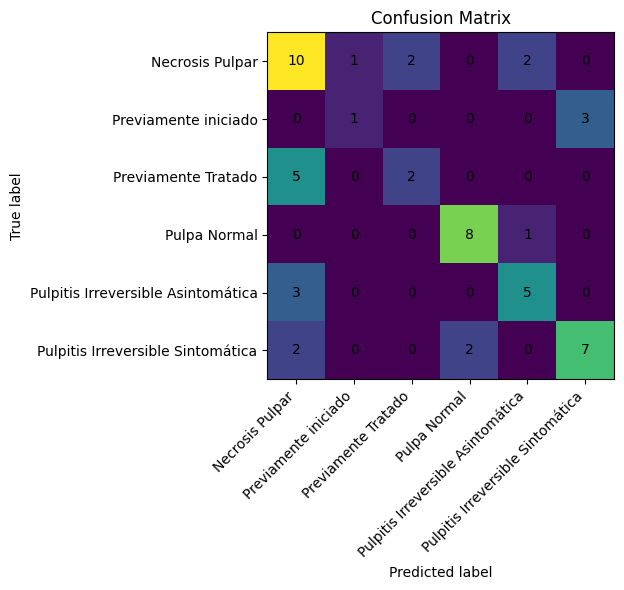

In [41]:
import matplotlib.pyplot as plt

def plot_confusion_matrix(cm, idx_to_class):
    labels = [idx_to_class[i] for i in sorted(idx_to_class.keys())]

    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(cm)

    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))

    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_yticklabels(labels)

    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_title("Confusion Matrix")

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha="center", va="center")

    plt.tight_layout()
    plt.show()

plot_confusion_matrix(results["confusion_matrix"], idx_to_class)


# Export the model

In [42]:
import torch
from pathlib import Path

save_dir = Path("saved_models")
save_dir.mkdir(exist_ok=True)

model_name = "FineDentalDeepGANew60Fold"

checkpoint_path = save_dir / f"{model_name}.pth"

checkpoint = {
    "model_state_dict": fold_model.state_dict(),
    "class_to_idx": class_to_idx,
    "idx_to_class": idx_to_class,
    "metrics": {
        "accuracy": results["accuracy"],
        "precision_macro": results["precision_macro"],
        "recall_macro": results["recall_macro"],
        "f1_macro": results["f1_macro"],
        "precision_weighted": results["precision_weighted"],
        "recall_weighted": results["recall_weighted"],
        "f1_weighted": results["f1_weighted"],
    },
}

torch.save(checkpoint, checkpoint_path)

print(f"Checkpoint guardado correctamente en: {checkpoint_path}")

Checkpoint guardado correctamente en: saved_models/FineDentalDeepGANew60Fold.pth


In [43]:
checkpoint = torch.load(checkpoint_path, map_location=device)

model = fold_model

model.load_state_dict(checkpoint["model_state_dict"])
model.to(device)
model.eval()

class_to_idx = checkpoint["class_to_idx"]
idx_to_class = checkpoint["idx_to_class"]

print(f"Checkpoint cargado correctamente desde: {checkpoint_path}")

Checkpoint cargado correctamente desde: saved_models/FineDentalDeepGANew60Fold.pth


In [44]:
from pathlib import Path
import torch

export_dir = Path("Models")
export_dir.mkdir(parents=True, exist_ok=True)

export_path = export_dir / f"{model_name}.pt2"

model_to_export = fold_model.eval().to("cpu")

dummy_image = torch.randn(1, 1, 128, 128)
dummy_clinical = torch.randn(1, 11)

with torch.no_grad():
    exported_program = torch.export.export(
        model_to_export,
        (dummy_image, dummy_clinical),
    )

torch.export.save(
    exported_program,
    str(export_path),
)

print(f"Modelo exportado correctamente a: {export_path}")

Modelo exportado correctamente a: Models/FineDentalDeepGANew60Fold.pt2


# Test the load model

In [45]:
import torch
import numpy as np

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
)


def load_pt2_for_inference(path, device):
    exported_program = torch.export.load(path)
    model = exported_program.module()
    model = model.to(device)
    return model


@torch.inference_mode()
def get_predictions(model, loader, device):
    all_preds = []
    all_targets = []

    for images, clinical_vectors, labels in loader:
        images = images.to(device, non_blocking=True)
        clinical_vectors = clinical_vectors.to(device, non_blocking=True)

        for i in range(images.size(0)):
            image_i = images[i:i+1]
            clinical_i = clinical_vectors[i:i+1]

            logits = model(image_i, clinical_i)
            pred = torch.argmax(logits, dim=1).item()

            all_preds.append(pred)
            all_targets.append(labels[i].item())

    return np.array(all_targets), np.array(all_preds)


def evaluate_classification_model(model, loader, device, idx_to_class):
    y_true, y_pred = get_predictions(model, loader, device)

    acc = accuracy_score(y_true, y_pred)

    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )

    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )

    labels = sorted(idx_to_class.keys())
    target_names = [idx_to_class[i] for i in labels]

    cm = confusion_matrix(y_true, y_pred, labels=labels)

    report = classification_report(
        y_true,
        y_pred,
        labels=labels,
        target_names=target_names,
        zero_division=0,
    )

    return {
        "accuracy": acc,
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "f1_macro": f1_macro,
        "precision_weighted": precision_weighted,
        "recall_weighted": recall_weighted,
        "f1_weighted": f1_weighted,
        "confusion_matrix": cm,
        "classification_report": report,
        "y_true": y_true,
        "y_pred": y_pred,
    }

In [46]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

model_pt2 = load_pt2_for_inference(
    export_path,
    device=device,
)

results = evaluate_classification_model(
    model=model_pt2,
    loader=data_module["loaders"]["test"],
    device=device,
    idx_to_class=idx_to_class,
)

print("Accuracy:", results["accuracy"])
print("F1 macro:", results["f1_macro"])
print(results["classification_report"])

/Users/mauricio/Documents/Ecuela-UV/Semestre-8/Servicio/DeepGA/.venv2/lib/python3.12/site-packages/torch/export/pt2_archive/_package.py:790: UserWarning: The given buffer is not writable, and PyTorch does not support non-writable tensors. This means you can write to the underlying (supposedly non-writable) buffer using the tensor. You may want to copy the buffer to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:1592.)
  tensor = torch.frombuffer(
/Users/mauricio/Documents/Ecuela-UV/Semestre-8/Servicio/DeepGA/.venv2/lib/python3.12/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
/var/folders/tl/kwq3tjcj1ys7lmb1pyf3jdd80000gn/T/ipykernel_4190/2383641742.py

Accuracy: 0.6111111111111112
F1 macro: 0.5670283663704716
                                    precision    recall  f1-score   support

                   Necrosis Pulpar       0.50      0.67      0.57        15
              Previamente iniciado       0.50      0.25      0.33         4
               Previamente Tratado       0.50      0.29      0.36         7
                      Pulpa Normal       0.80      0.89      0.84         9
Pulpitis Irreversible Asintomática       0.62      0.62      0.62         8
 Pulpitis Irreversible Sintomática       0.70      0.64      0.67        11

                          accuracy                           0.61        54
                         macro avg       0.60      0.56      0.57        54
                      weighted avg       0.61      0.61      0.60        54



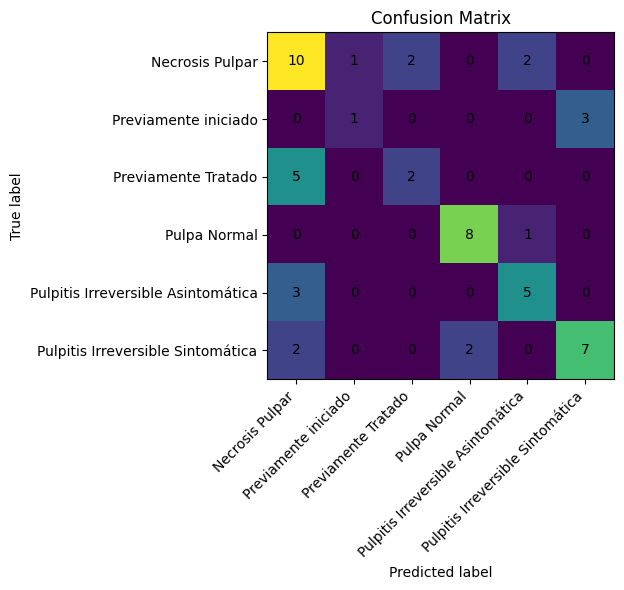

In [47]:
import matplotlib.pyplot as plt

def plot_confusion_matrix(cm, idx_to_class):
    labels = [idx_to_class[i] for i in sorted(idx_to_class.keys())]

    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(cm)

    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))

    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_yticklabels(labels)

    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_title("Confusion Matrix")

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha="center", va="center")

    plt.tight_layout()
    plt.show()

plot_confusion_matrix(results["confusion_matrix"], idx_to_class)
